# Create Renewable Energy Zones mask

In [1]:
import xarray as xr
import geopandas
import regionmask

In [10]:
def create_mask(gpd_df, template_ds, boundary=None, lon_name='lon', lat_name='lat'):
    """
    Create mask from shapefiles and a template xarray dataArray or dataset.
    """
    mask = regionmask.mask_3D_geopandas(
        gpd_df,
        template_ds[lon_name],
        template_ds[lat_name]
    )
    
    if lon_name != 'lon':
        mask = mask.rename({lon_name: 'lon'})
    if lat_name != 'lat':
        mask = mask.rename({lat_name: 'lat'})
        
    if isinstance(boundary, list):
        mask = mask.sel(
            lon=slice(boundary[0], boundary[1]),
            lat=slice(boundary[2], boundary[3])
        )
        
    return mask

In [19]:
# ALready computed shapefile from other project
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp"
)

In [20]:
rez_gpd.head()

,Name,Type,code_2023,code_SC205,longitude,latitude,geometry
0,Q1 Far North QLD,REZ,1,1,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0.00000, 146.0..."
1,Q2 North Qld Clean Energy Hub,REZ,3,3,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0.00000, 143.8..."
2,Q3 Northern Qld,REZ,2,2,146.333143,-19.197589,"POLYGON Z ((146.27782 -18.71920 0.00000, 146.2..."
3,Q4 Isaac,REZ,3,3,148.339869,-21.393793,"POLYGON Z ((147.64366 -19.94015 0.00000, 147.6..."
4,Q5 Barcaldine,REZ,2,3,145.595326,-22.855731,"POLYGON Z ((145.82086 -23.84279 0.00000, 145.7..."


In [7]:
barra_instance = xr.open_dataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/orog/v20240516/orog_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc"
)

In [9]:
barra_instance.dims

FrozenMappingWarningOnValuesAccess({'lat': 1018, 'lon': 1298})

In [24]:
rez_mask = create_mask(
    rez_gpd,
    barra_instance,
    [110, 155, -45, -10]
)

/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/regionmask/core/mask.py:444: UserWarning: Detected overlapping regions. As of v0.11.0 these are correctly taken into account. Note, however, that a different mask is returned than with older versions of regionmask. To suppress this warning, set `overlap=True` (to restore the old, incorrect, behaviour, set `overlap=False`).
  warnings.warn(


In [32]:
rez_codes = rez_gpd["Name"]
rez_codes = [i.split(" ")[0] for i in rez_codes]

In [35]:
rez_mask = rez_mask.assign_coords({
    "region": rez_codes
})

In [40]:
rez_mask = rez_mask.drop("crs")

/jobfs/149420352.gadi-pbs/ipykernel_3112420/1218372899.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  rez_mask = rez_mask.drop("crs")


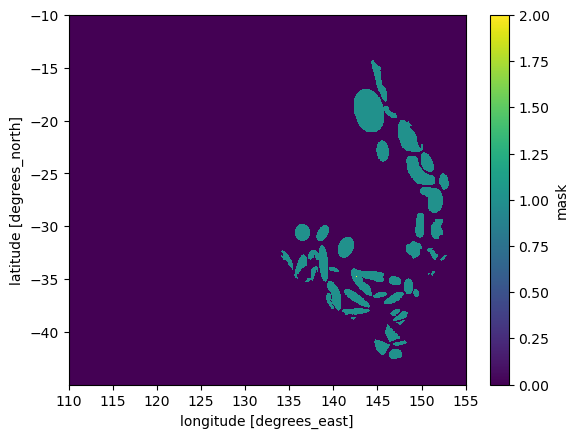

In [44]:
rez_mask.sum("region").plot()

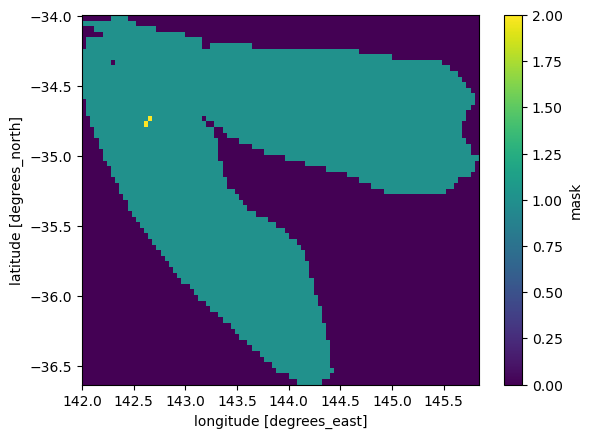

In [75]:
# Note there is 2 grid cells overlapping between N5 and V2.
rez_mask.sel(region=["N5", "V2"]).where(rez_mask.sel(region=["N5", "V2"]), drop=True).sum("region").plot()

In [41]:
rez_mask_ds = rez_mask.to_dataset(name='REZ')
rez_mask_ds.to_netcdf('/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_BARRA-C2_grid.nc')